# Load Data

In [1]:
import pickle

In [2]:
with open('orbitals.pkl', 'rb') as f:
    orbitals = pickle.load(f)

with open('maneuvers.pkl', 'rb') as f:
    maneuvers = pickle.load(f)

# Check day time uniform and interpolate

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from datetime import datetime

In [4]:
man = maneuvers['s3a']

In [5]:
df = orbitals['Sentinel-3A.csv'].copy()
df = df[['Brouwer mean motion']].copy()
df.rename(columns={"Brouwer mean motion": "mean_motion"}, inplace=True)

In [6]:
df.index = pd.to_datetime(df.index)

# keep only year-month-day
df.index = df.index.normalize()

In [7]:
df.index.duplicated().any()

False

In [8]:
df.index = pd.to_datetime(df.index)
diffs = df.index.to_series().diff()
is_uniform = diffs[1:] == diffs[1]

print(f"is uniform interval in days?：{is_uniform.all()}")
print(f"interval count：{diffs.value_counts().head()}")

is uniform interval in days?：False
interval count：day_time
1 days    2373
2 days       7
3 days       3
4 days       1
Name: count, dtype: int64


In [9]:
most_common_diff = diffs.value_counts().idxmax()

# check which dates have problems
irregular_times = diffs[diffs != most_common_diff]

print("Following dtaes records not in uniform：")
print(irregular_times) # without 16-03-04 as this date is initial strart day

Following dtaes records not in uniform：
day_time
2016-03-04      NaT
2016-09-24   2 days
2016-09-28   2 days
2019-07-12   2 days
2019-08-12   2 days
2019-11-09   2 days
2019-11-16   2 days
2020-03-13   3 days
2020-11-11   4 days
2021-05-19   2 days
2022-04-02   3 days
2022-06-19   3 days
Name: day_time, dtype: timedelta64[ns]


In [10]:
# df = df.asfreq('D')  # set day as freq
# df = df.interpolate() 

In [11]:
df.index = pd.to_datetime(df.index)
diffs = df.index.to_series().diff()
is_uniform = diffs[1:] == diffs[1]

print(f"is uniform interval in days?：{is_uniform.all()}")
print(f"interval count：{diffs.value_counts().head()}")

is uniform interval in days?：False
interval count：day_time
1 days    2373
2 days       7
3 days       3
4 days       1
Name: count, dtype: int64


# Time-series Plot

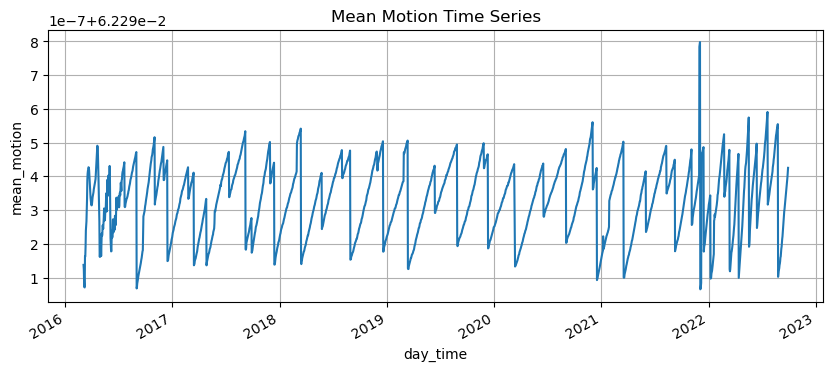

In [12]:
plt.figure(figsize=(10, 4))
df['mean_motion'].plot(title='Mean Motion Time Series')
plt.ylabel("mean_motion")
plt.grid(True)
plt.show()

# Set up random environment

In [13]:
import tensorflow as tf
import random

In [14]:
def set_seed(seed=42):
    
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    
    os.environ['TF_DETERMINISTIC_OPS'] = '1'

set_seed(42)

# Split data and pre-process

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error


from itertools import product
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, LSTM,  Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.losses import MeanSquaredError, MeanAbsoluteError

In [16]:
features = df[['mean_motion']]

# determine split indices
total_samples = len(features)
train_size = int(total_samples * 0.8)

# split the data
train_data = features[:train_size]
test_data = features[train_size:]

scaler = MinMaxScaler()

# fit scalers on training data and transform
train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)

In [17]:
print(train_data.shape, test_data.shape)

(1908, 1) (477, 1)


In [18]:
def create_sequences(data, window_size):
    sequences = []
    targets = []
    for i in range(len(data) - window_size):
        seq = data[i:i + window_size]
        target = data[i + window_size][0]  # predicting 'Close' price
        sequences.append(seq)
        targets.append(target)
    return np.array(sequences), np.array(targets)

# Define LSTM Model

In [19]:
# define models
def create_lstm_model(window_size, n_features, learning_rate=0.001):
	model = Sequential()
	model.add(Input(shape=(window_size, n_features)))
	model.add(LSTM(50)) # refer to github work original set up number
	model.add(Dense(10, activation='tanh'))
	model.add(Dense(1))
	optimizer = Adam(learning_rate=learning_rate) # refer to github work original set up number
	criterion = MeanAbsoluteError(reduction='sum_over_batch_size')
	model.compile(optimizer, loss=criterion)
	# model.compile(optimizer='adam', loss='mse')
	return model

# Tuning learning rate for models

In [20]:
window_size = 5
learning_rates = [0.1, 0.01, 1e-3, 1e-4]
results = []
histories = []  

In [21]:
# early stopping callback
early_stop = EarlyStopping(monitor='val_loss', patience=10, min_delta=1e-5)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
callbacks = [early_stop, reduce_lr]

In [22]:
for learning_rate in learning_rates:
    print(f"\nTraining models with learning rate: {learning_rate}")

    # create sequences for training, validation, and testing
    X_train, y_train = create_sequences(train_scaled, window_size)
    X_test, y_test = create_sequences(test_scaled, window_size)
    
    # reshape input data to 3D (samples, time steps, features)
    n_features = X_train.shape[2]
    X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], n_features))
    X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], n_features))

    models = {
        'LSTM': create_lstm_model(window_size, n_features, learning_rate=learning_rate)
    }

    # train and evaluate each model
    for model_name, model in models.items():
        print(f"\nTraining {model_name} model...")
        history = model.fit(
            X_train, 
            y_train,
            epochs=30,
            batch_size=32,
            validation_data=(X_test, y_test),
            callbacks=callbacks,
            shuffle=False, #repeated result
            verbose=0  # hide process
        )

        # make predictions
        y_test_pred = model.predict(X_test)

        # inverse transform predictions and actual values
        y_test_pred_inv = scaler.inverse_transform(np.concatenate([y_test_pred, np.zeros((y_test_pred.shape[0], n_features - 1))], axis=1))[:, 0]
        y_test_actual_inv = scaler.inverse_transform(np.concatenate([y_test.reshape(-1,1), np.zeros((y_test.shape[0], n_features - 1))], axis=1))[:, 0]

        # calculate performance metrics rmse, mae, mape
        mae = mean_absolute_error(y_test_actual_inv, y_test_pred_inv)
        
        # directional accuarcy
        direction_actual = np.sign(np.diff(y_test_actual_inv))
        direction_pred = np.sign(np.diff(y_test_pred_inv))
        directional_accuracy = np.mean(direction_actual == direction_pred) * 100


        print(f"{model_name} MAE: {mae:.4f}")
        
        histories.append({
            'Learning Rate': learning_rate,
            'Model': model_name,
            'History': history.history
        })
        
        # save results
        results.append({
            'Learning Rate': learning_rate,
            'Model': model_name,
            'MAE': mae,
            'Direction Acc': directional_accuracy       
                })


Training models with learning rate: 0.1

Training LSTM model...
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
LSTM MAE: 0.0000

Training models with learning rate: 0.01

Training LSTM model...
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
LSTM MAE: 0.0000

Training models with learning rate: 0.001

Training LSTM model...
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
LSTM MAE: 0.0000

Training models with learning rate: 0.0001

Training LSTM model...
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
LSTM MAE: 0.0000


In [23]:
lr_res = pd.DataFrame(results)
print(lr_res)

   Learning Rate Model           MAE  Direction Acc
0         0.1000  LSTM  9.684065e-08      87.898089
1         0.0100  LSTM  1.580539e-08      93.630573
2         0.0010  LSTM  3.494324e-08      83.864119
3         0.0001  LSTM  4.294537e-08      83.864119


select lr = 0.01

# Tuning hyperparamters

In [24]:
set_seed(42)

In [25]:
# define models
def create_lstm_model(window_size, n_features, hidden_units, dropout_rate, fc_size, learning_rate):
	model = Sequential()
	model.add(Input(shape=(window_size, n_features)))
	model.add(LSTM(hidden_units))
	model.add(Dropout(dropout_rate))
	model.add(Dense(fc_size, activation='tanh'))
	model.add(Dense(1))
	optimizer = Adam(learning_rate=learning_rate) # refer to github work original set up number
	criterion = MeanAbsoluteError(reduction='sum_over_batch_size')
	model.compile(optimizer, loss=criterion)
	return model

In [26]:
window_size = 5
learning_rate = 0.01
hidden_units_list = [16, 32, 64, 128]       # hidden unit sizes
dropout_rates = [0.3, 0.5, 0.7]               # dropout rates
fc_sizes = [8, 16]                      # fully connected layer sizes

results = []
histories = []

In [27]:
# early stopping callback
early_stop = EarlyStopping(monitor='val_loss', patience=10, min_delta=1e-5)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
callbacks = [early_stop, reduce_lr]

In [28]:
for hidden_units, dropout_rate, fc_size in product(hidden_units_list, dropout_rates, fc_sizes):
    print(f"\n fixed para: LR={learning_rate}, Window size={window_size}")
    print(f"\nTraining LSTM with Hidden Units: {hidden_units}, Dropout Rate: {dropout_rate}, FC Size: {fc_size}")
    
    # create series
    X_train, y_train = create_sequences(train_scaled, window_size)
    X_test, y_test = create_sequences(test_scaled, window_size)
    
    # reshape input data to 3D (samples, time steps, features)
    n_features = X_train.shape[2]
    X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], n_features))
    X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], n_features))
    
    # define models
    model = create_lstm_model(window_size=window_size, n_features=n_features, learning_rate=learning_rate, 
                             hidden_units=hidden_units, 
                             dropout_rate=dropout_rate, 
                             fc_size=fc_size)
    
    history = model.fit(
            X_train, 
            y_train,
            epochs=30,
            batch_size=32,
            validation_data=(X_test, y_test),
            callbacks=callbacks,
            shuffle=False,  # ensure repeated
            verbose=0  # hide process
        )
        
        
	# check predict 
    y_test_pred = model.predict(X_test)
	
	# inverse transform predictions and actual values
    y_test_pred_inv = scaler.inverse_transform(np.concatenate([y_test_pred, np.zeros((y_test_pred.shape[0], n_features - 1))], axis=1))[:, 0]
    y_test_actual_inv = scaler.inverse_transform(np.concatenate([y_test.reshape(-1,1), np.zeros((y_test.shape[0], n_features - 1))], axis=1))[:, 0]
	
	# calculate performance metrics rmse, mae, mape
    mae = mean_absolute_error(y_test_actual_inv, y_test_pred_inv)
	
	# directional accuarcy
    direction_actual = np.sign(np.diff(y_test_actual_inv))
    direction_pred = np.sign(np.diff(y_test_pred_inv))
    directional_accuracy = np.mean(direction_actual == direction_pred) * 100
	
    print(f"LSTM MAE: {mae:.4f}")
    
    histories.append({
		'Hidden Units': hidden_units,
		'Dropout Rate': dropout_rate,
		'FC Size': fc_size,
		'Model': 'LSTM',
		'History': history.history
	})
    
    # save result
    results.append({
		'Hidden Units': hidden_units,
		'Dropout Rate': dropout_rate,
		'FC Size': fc_size,
		'Model': 'LSTM',
		'MAE': mae,
		'Direction Acc': directional_accuracy
	})


 fixed para: LR=0.01, Window size=5

Training LSTM with Hidden Units: 16, Dropout Rate: 0.3, FC Size: 8
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
LSTM MAE: 0.0000

 fixed para: LR=0.01, Window size=5

Training LSTM with Hidden Units: 16, Dropout Rate: 0.3, FC Size: 16
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
LSTM MAE: 0.0000

 fixed para: LR=0.01, Window size=5

Training LSTM with Hidden Units: 16, Dropout Rate: 0.5, FC Size: 8
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
LSTM MAE: 0.0000

 fixed para: LR=0.01, Window size=5

Training LSTM with Hidden Units: 16, Dropout Rate: 0.5, FC Size: 16
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
LSTM MAE: 0.0000

 fixed para: LR=0.01, Window size=5

Training LSTM with Hidden Units: 16, Dropout Rate: 0.7, FC Size: 8
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
LSTM MAE: 0.0000

 fixed para: LR=0.01, Window size=5

Training LSTM with Hidden Units: 16, Dropout Rate: 0.7, FC Size: 16
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
LSTM MAE: 0.0000

 fixed para: LR=0.01, Window s

In [29]:
tuned_res_lstm = pd.DataFrame(results)
print(tuned_res_lstm.sort_values(by='MAE', ascending=True))

    Hidden Units  Dropout Rate  FC Size Model           MAE  Direction Acc
6             32           0.3        8  LSTM  1.647946e-08      92.569002
12            64           0.3        8  LSTM  1.650668e-08      93.205945
1             16           0.3       16  LSTM  1.661172e-08      91.719745
21           128           0.5       16  LSTM  1.712627e-08      91.507431
18           128           0.3        8  LSTM  1.825813e-08      94.055202
2             16           0.5        8  LSTM  1.829364e-08      90.870488
9             32           0.5       16  LSTM  1.884539e-08      89.596603
15            64           0.5       16  LSTM  1.998160e-08      90.445860
13            64           0.3       16  LSTM  2.026985e-08      91.932059
22           128           0.7        8  LSTM  2.051064e-08      91.082803
0             16           0.3        8  LSTM  2.127800e-08      93.842887
8             32           0.5        8  LSTM  2.166329e-08      91.295117
17            64         

In [30]:
tuned_res_lstm_sorted = tuned_res_lstm.sort_values(by='MAE', ascending=True)
tuned_res_lstm_sorted.reset_index(drop=True, inplace=True)

tuned_res_lstm_sorted['Model'] = tuned_res_lstm_sorted['Model'].astype(str)
top_n = 5
top_configs = tuned_res_lstm_sorted.groupby('Model').head(top_n).reset_index(drop=True)

print(top_configs)

   Hidden Units  Dropout Rate  FC Size Model           MAE  Direction Acc
0            32           0.3        8  LSTM  1.647946e-08      92.569002
1            64           0.3        8  LSTM  1.650668e-08      93.205945
2            16           0.3       16  LSTM  1.661172e-08      91.719745
3           128           0.5       16  LSTM  1.712627e-08      91.507431
4           128           0.3        8  LSTM  1.825813e-08      94.055202


# Fit with tuned LSTM models

In [31]:
features = df[['mean_motion']]  # using only mean_motion
scaler = MinMaxScaler()
scaled_all = scaler.fit_transform(features)

In [32]:
print(len(scaled_all))

2385


In [33]:
window_size = 5

X_all, y_all = create_sequences(scaled_all, window_size)
n_features = X_all.shape[2]
X_all = X_all.reshape((X_all.shape[0], X_all.shape[1], n_features))

In [34]:
print(X_all.shape[0], y_all.shape[0])

2380 2380


In [35]:
set_seed(42)

In [36]:
# define models
def create_lstm_model(window_size, n_features, learning_rate, hidden_units, dropout_rate, fc_size):
	model = Sequential()
	model.add(Input(shape=(window_size, n_features)))
	model.add(LSTM(hidden_units))
	model.add(Dropout(dropout_rate))
	model.add(Dense(fc_size, activation='tanh'))
	model.add(Dense(1))
	optimizer = Adam(learning_rate=learning_rate) # refer to github work original set up number
	criterion = MeanAbsoluteError(reduction='sum_over_batch_size')
	model.compile(optimizer, loss=criterion)
	return model

In [37]:
lstm_params = {'learning_rate': 0.01,
               'hidden_units': 64, 
               'dropout_rate': 0.3, 
               'fc_size': 8}

In [38]:
model_lstm = create_lstm_model(window_size, n_features, **lstm_params)

In [39]:
reduce_lr = ReduceLROnPlateau(monitor='loss', factor=0.5, patience=5, min_lr=1e-6)
callbacks = [reduce_lr]

In [40]:
history_lstm = model_lstm.fit(X_all, y_all, epochs=20, batch_size=32, shuffle=False, callbacks=callbacks, verbose=0)

In [41]:
y_pred_scaled = model_lstm.predict(X_all)
y_pred = scaler.inverse_transform(np.concatenate([y_pred_scaled, np.zeros((y_pred_scaled.shape[0], n_features - 1))], axis=1))[:, 0]
y_actual = scaler.inverse_transform(np.concatenate([y_all.reshape(-1,1), np.zeros((y_all.shape[0], n_features - 1))], axis=1))[:, 0]

75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


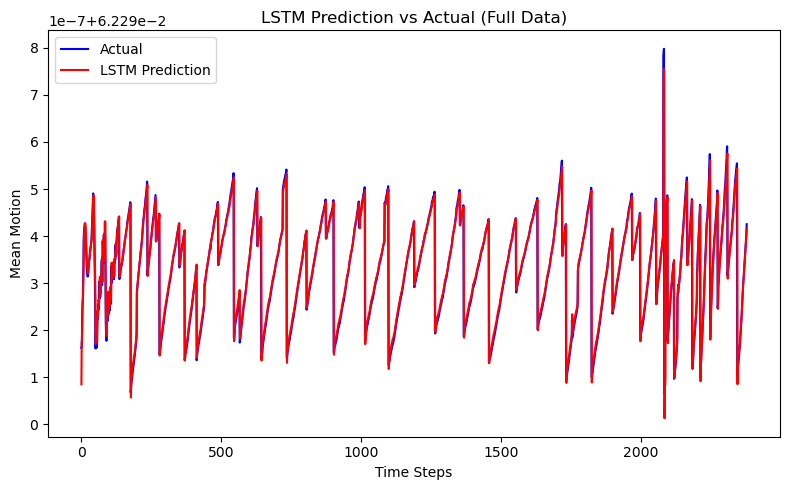

In [42]:
plt.figure(figsize=(8, 5))
plt.plot(y_actual, label='Actual', color='blue')
plt.plot(y_pred, label='LSTM Prediction', color='red')
plt.title('LSTM Prediction vs Actual (Full Data)')
plt.xlabel('Time Steps')
plt.ylabel('Mean Motion')
plt.legend()
plt.tight_layout()
plt.show()

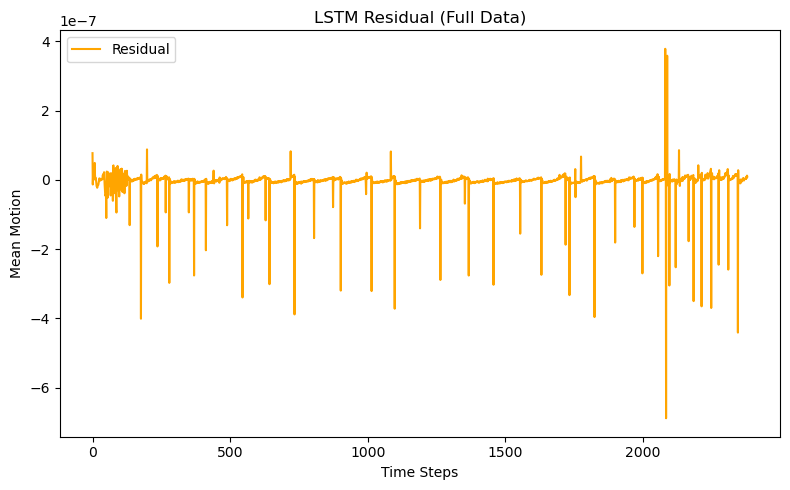

In [43]:
plt.figure(figsize=(8, 5))
plt.plot(y_actual - y_pred, label='Residual', color='orange')
plt.title('LSTM Residual (Full Data)')
plt.xlabel('Time Steps')
plt.ylabel('Mean Motion')
plt.legend()
plt.tight_layout()
plt.show()

In [44]:
full_index = df.index
aligned_index = full_index[window_size:]

lstm_pred = pd.DataFrame({
    'actual': y_actual,
    'pred':   y_pred
}, index = aligned_index)

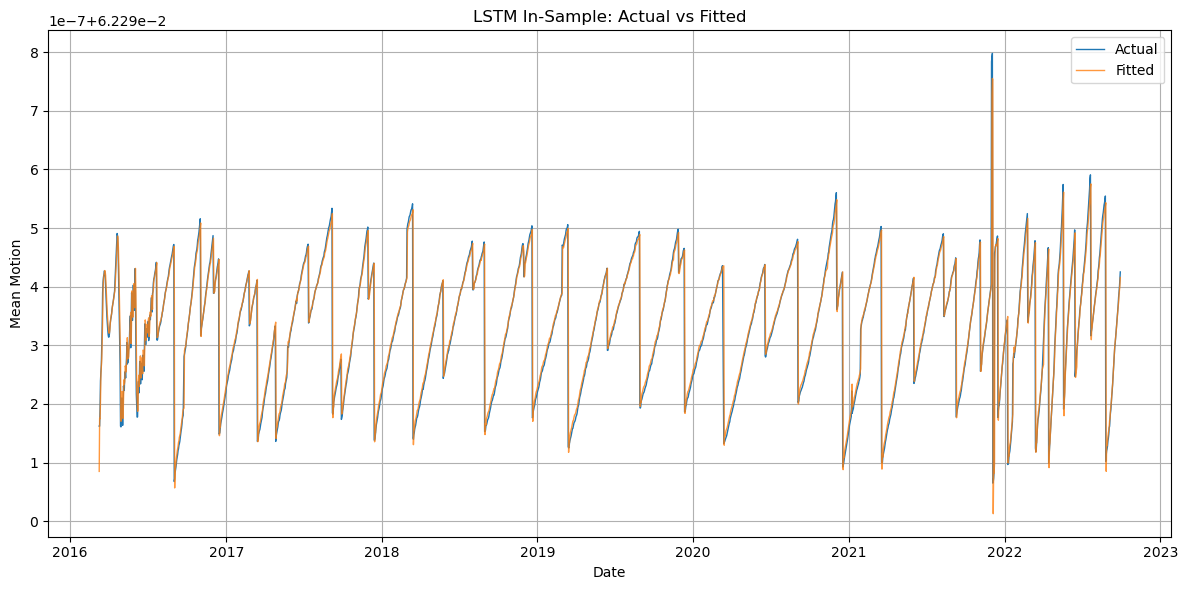

In [45]:
plt.figure(figsize=(12, 6))
plt.plot(lstm_pred.index, lstm_pred["actual"], label="Actual", linewidth=1)
plt.plot(lstm_pred.index, lstm_pred["pred"], label="Fitted", linewidth=1, alpha=0.8)

plt.title("LSTM In‑Sample: Actual vs Fitted")
plt.xlabel("Date")
plt.ylabel("Mean Motion")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Get LSTM Residual from prediction vs true value

In [46]:
# xgb_pred['residual_orig'] = xgb_pred['actual_orig'] - xgb_pred['pred_orig']
lstm_pred['residual'] = lstm_pred['actual'] - lstm_pred['pred']

In [47]:
lstm_pred.to_csv("result/s3a_lstm_residuals.csv", index=True)

# Check residuals - distribution and QQ

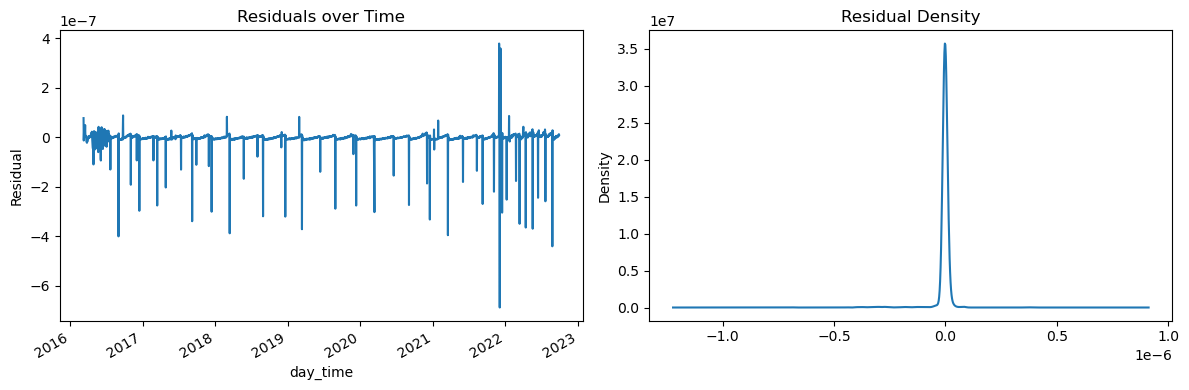

In [48]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

lstm_pred['residual'].plot(ax=ax[0], title="Residuals over Time")
ax[0].set_ylabel("Residual")

lstm_pred['residual'].plot(kind='kde', ax=ax[1], title="Residual Density")

plt.tight_layout()
plt.show()

In [49]:
import scipy.stats as stats

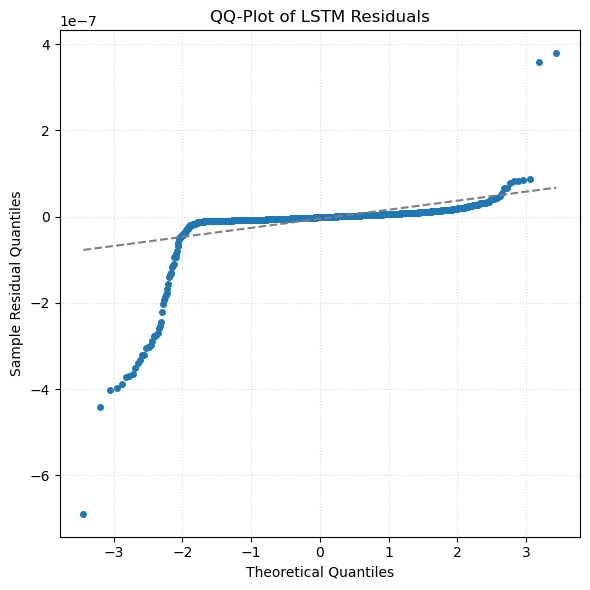

In [50]:
lstm_res = lstm_pred['residual']

# get qq plts for res
fig, ax = plt.subplots(figsize=(6,6))
stats.probplot(lstm_res, dist="norm", plot=ax)

dots, line = ax.get_lines()
dots.set_marker('o')
dots.set_markersize(4)
dots.set_color('tab:blue')

line.set_linestyle('--')
line.set_color('tab:gray')

ax.grid(True, linestyle=':', alpha=0.5)
ax.set_title("QQ-Plot of LSTM Residuals")
ax.set_xlabel("Theoretical Quantiles")
ax.set_ylabel("Sample Residual Quantiles")

plt.tight_layout()
plt.show()

# Extract anomlies

In [51]:
import scipy.stats as sts

In [52]:
# get means and var for res
mu    = lstm_res.mean()
sigma = lstm_res.std()

In [53]:
# p_low, p_high = sts.norm.cdf([-2.1, +2.6])
# print("percentile range", p_low, p_high)

In [54]:
# low, high = lstm_res.quantile([p_low, p_high])
# print("anomlies thresholds selected：", low, high)

# # get anomalies
# anomalies = lstm_res[(lstm_res < low) | (lstm_res > high)]
anomalies = lstm_res[np.abs(lstm_res - mu) > 2 * sigma]
print("num of anomalies：", len(anomalies))

num of anomalies： 50


# Visulize result

In [55]:
manoeuvre_dates = pd.to_datetime(man['median_day_time']).dt.date
manoeuvre_dates = pd.to_datetime(manoeuvre_dates)
manoeuvre_dates = manoeuvre_dates[manoeuvre_dates.isin(df.index)]

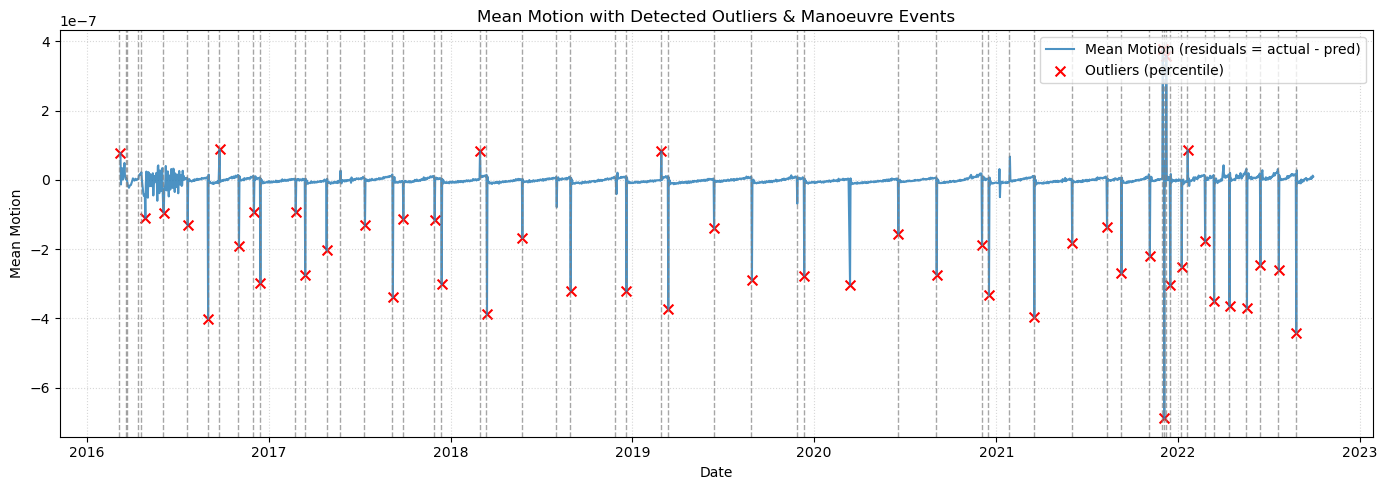

In [56]:
plt.figure(figsize=(14, 5))

# # 1) plt actual
# plt.plot(arima_pred.index, 
#          arima_pred['actual'], 
#          label='Mean Motion (actual)', 
#          color='C0', 
#          alpha=0.8)

# 1) plt -residuals
plt.plot(lstm_pred.index, 
         lstm_pred['residual'], 
         label='Mean Motion (residuals = actual - pred)', 
         color='C0', 
         alpha=0.8)

# 2) plt man
for dt in manoeuvre_dates:
    plt.axvline(x=dt,
                color='gray',
                linestyle='--',
                linewidth=1,
                alpha=0.7)
    
# 3) plt anomalies
plt.scatter(
    anomalies.index,
    lstm_pred.loc[anomalies.index, 'residual'],
    color='red',
    marker='x',
    s=50,
    label='Outliers (percentile)'
)

plt.title("Mean Motion with Detected Outliers & Manoeuvre Events")
plt.xlabel("Date")
plt.ylabel("Mean Motion")
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

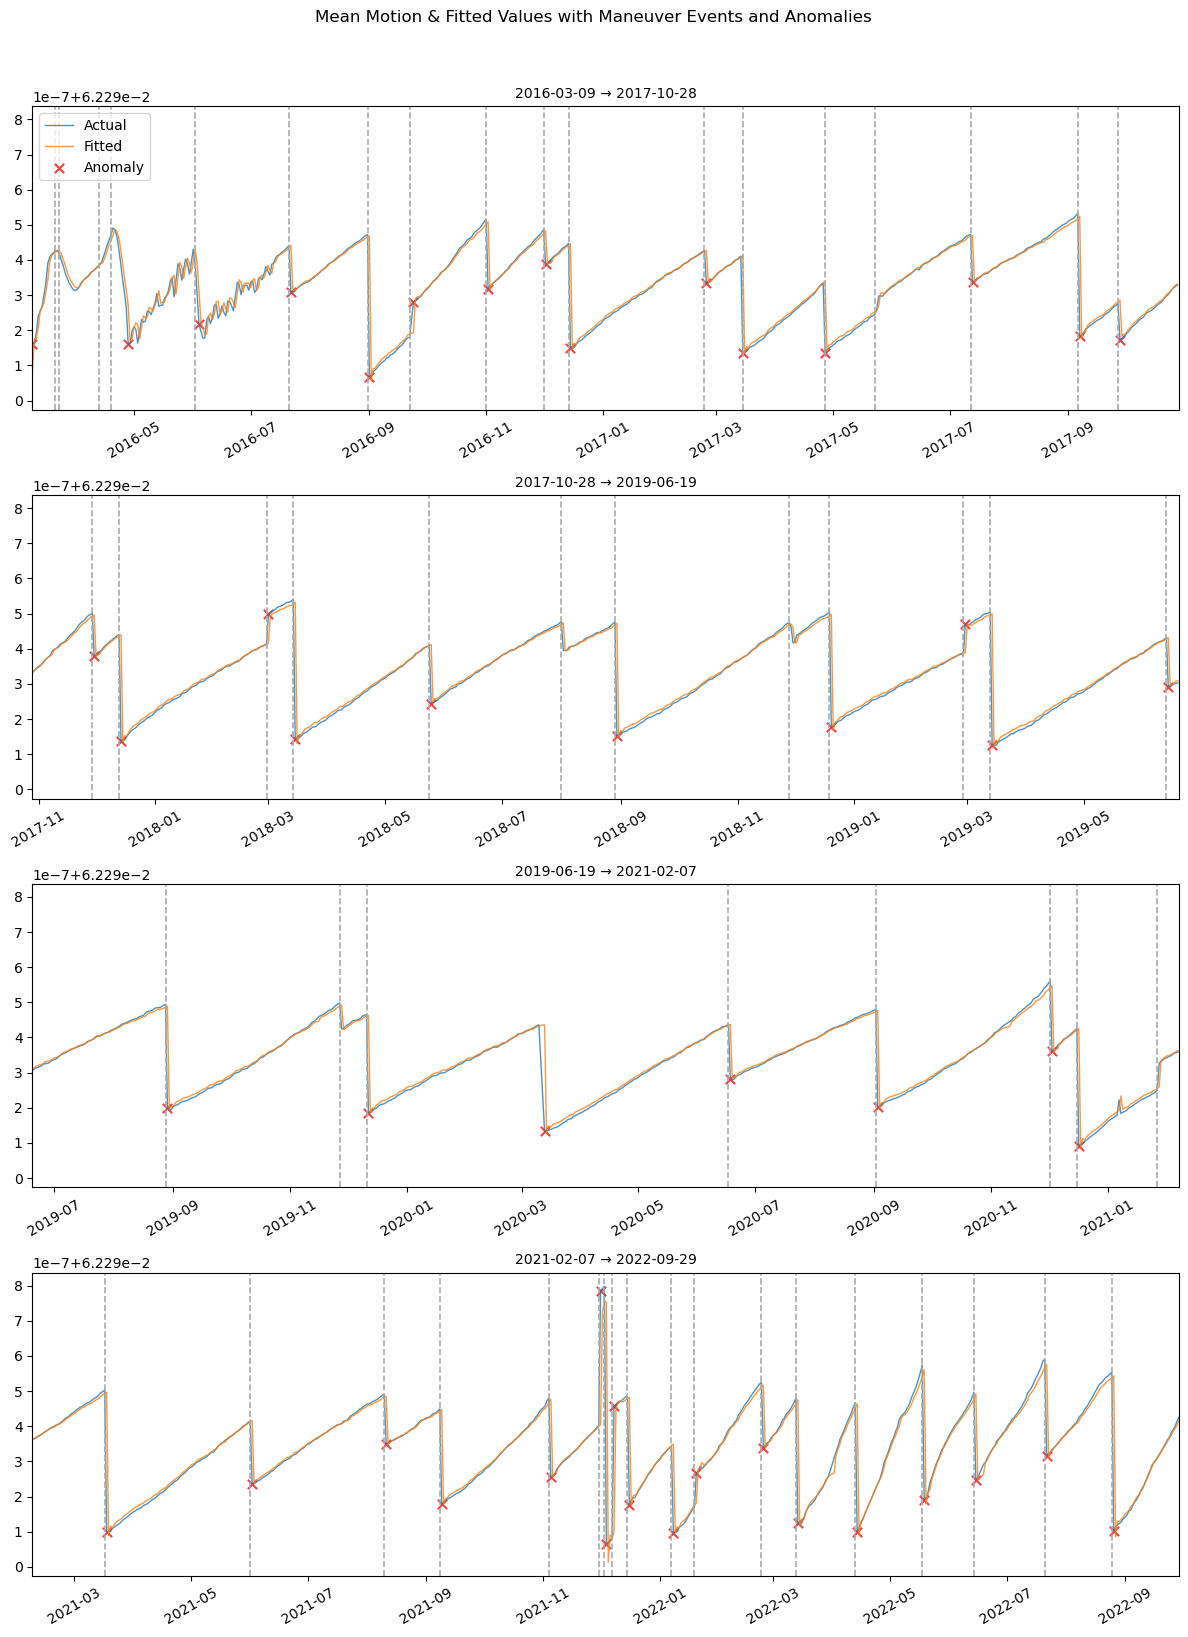

In [57]:
# get multi-cols plts
start, end = lstm_pred.index.min(), lstm_pred.index.max()
knots = pd.date_range(start, end, periods=5)
intervals = list(zip(knots[:-1], knots[1:]))

fig, axes = plt.subplots(4, 1, figsize=(12, 16), sharey=True)

for ax, (seg_start, seg_end) in zip(axes, intervals):
    segment = lstm_pred.loc[seg_start:seg_end]
    
    # actual
    ax.plot(
        segment.index, segment['actual'],
        label='Actual', color='#1f77b4', alpha=0.8, linewidth=1.0
    )
    # plt fitted
    ax.plot(
        segment.index, segment['pred'],
        label='Fitted', color='#ff7f0e', alpha=0.8, linewidth=1.0
    )
    
    # # plt -residuals
    # plt.plot(arima_pred.index, 
	# 		arima_pred['residual'], 
	# 		label='Mean Motion (residuals = actual - pred)', 
	# 		color='C0', 
	# 		alpha=0.8)
    
    # 3) plt anomalies
    idx1 = anomalies.loc[seg_start:seg_end].index
    ax.scatter(
        idx1,
        segment.loc[idx1, 'actual'],
        color='red', 
        marker='x',
        alpha = 0.75,
        s=45,
        label='Anomaly'
    )
    
    # 4) plt man
    for dt in manoeuvre_dates:
        if seg_start <= dt <= seg_end:
            ax.axvline(
                x=dt, color='#aaaaaa',
                linestyle='--', linewidth=1.2, alpha=1.0
            )
    
    # tight layout
    ax.set_xlim(seg_start, seg_end)
    # ax.grid(True, linestyle=':', alpha=0.5)
    ax.set_title(f"{seg_start.date()} → {seg_end.date()}", fontsize=10)
    ax.tick_params(axis='x', rotation=30)
    
    if ax is axes[0]:
        ax.legend(loc='upper left')

fig.suptitle(
    "Mean Motion & Fitted Values with Maneuver Events and Anomalies",
    y=1.02, fontsize=12
)
plt.tight_layout()
plt.show()

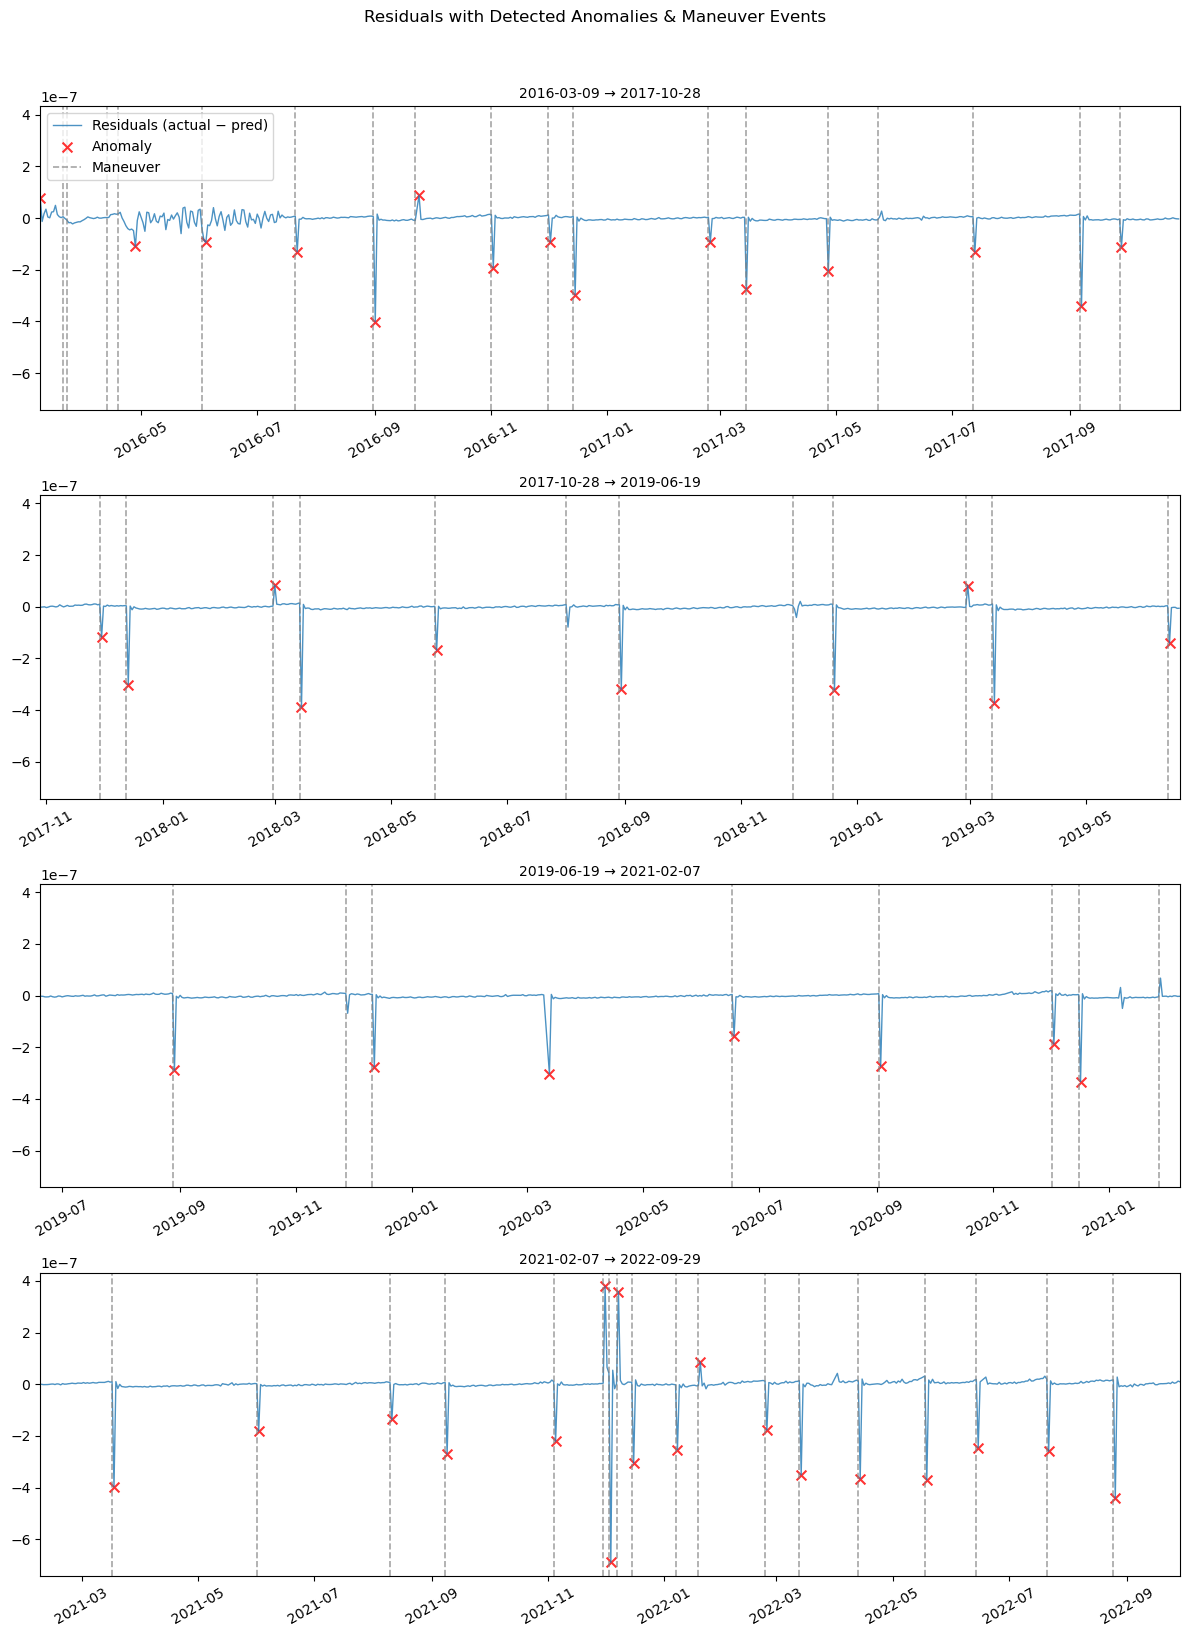

In [58]:
# residuals

fig, axes = plt.subplots(4, 1, figsize=(12, 16), sharey=True)

for ax, (seg_start, seg_end) in zip(axes, intervals):
    segment = lstm_pred.loc[seg_start:seg_end]
    
    ax.plot(
        segment.index, segment['residual'],
        label='Residuals (actual − pred)',
        color='C0', alpha=0.8, linewidth=1.0
    )

    idx1 = anomalies.loc[seg_start:seg_end].index
    ax.scatter(
        idx1, segment.loc[idx1, 'residual'],
        color='red', marker='x', s=50, alpha=0.8,
        label='Anomaly'
    )
    
    first = True
    for dt in manoeuvre_dates:
        if seg_start <= dt <= seg_end:
            ax.axvline(
                x=dt, color='gray', linestyle='--',
                linewidth=1.2, alpha=0.7,
                label='Maneuver' if first else None
            )
            first = False
    
    ax.set_xlim(seg_start, seg_end)
    ax.set_title(f"{seg_start.date()} → {seg_end.date()}", fontsize=10)
    ax.tick_params(axis='x', rotation=30)
    if ax is axes[0]:
        ax.legend(loc='upper left')

fig.suptitle(
    "Residuals with Detected Anomalies & Maneuver Events",
    y=1.02, fontsize=12
)
plt.tight_layout()
plt.show()

# Record num of man and anomlies

In [59]:
# records num of anomlies and man
man_df   = man.copy()             # man
anom_idx = anomalies.index        # outliers index

man_days  = pd.to_datetime(man_df['median_day_time']).dt.normalize()
anom_days = anom_idx.normalize()

anom_set = set(anom_days)

# check deteced in +- n days range
n = 3 

matched_manoeuvres = []
unmatched_manoeuvres = []

for d in man_days:
    window = set(d + pd.to_timedelta(offset, unit='D') for offset in range(-n, n+1))
    
    if window & anom_set:
        matched_manoeuvres.append(d)
    else:
        unmatched_manoeuvres.append(d)

summary = pd.DataFrame({
    "category": [
        "total_manoeuvres",
        "total_anomalies",
        f"manoeuvres_matched_within_±{n}d",
        f"manoeuvres_unmatched_within_±{n}d"
    ],
    "count": [
        len(man_days),
        len(anom_days),
        len(matched_manoeuvres),
        len(unmatched_manoeuvres)
    ]
})

summary

,category,count
0,total_manoeuvres,64
1,total_anomalies,50
2,manoeuvres_matched_within_±3d,49
3,manoeuvres_unmatched_within_±3d,15


In [60]:
summary.to_csv("result/s3a_lstm_result.csv", index=False)